In [21]:
# Veri Bilimi Projesi
# Modeller: KNN, SVM, Karar Ağacı, Random Forest, YSA, CNN

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_curve, roc_auc_score
from sklearn.inspection import permutation_importance
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Conv1D, MaxPooling1D, Flatten
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
import warnings
warnings.filterwarnings('ignore')

In [22]:
# 1. VERİ YÜKLEME VE ÖN İŞLEME

df = pd.read_csv('bank-additional-full.csv', sep=';')
df['y'] = df['y'].map({'yes': 1, 'no': 0})

numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
if 'y' in numeric_cols:
    numeric_cols.remove('y')

cat_cols = df.select_dtypes(include=['object']).columns.tolist()
df_encoded = pd.get_dummies(df, columns=cat_cols, drop_first=True)

X = df_encoded.drop('y', axis=1)
y = df_encoded['y']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Eğitim seti: {X_train_scaled.shape}, Test seti: {X_test_scaled.shape}")
print(f"Sınıf dağılımı (eğitim): {y_train.value_counts().to_dict()}")

Eğitim seti: (32950, 53), Test seti: (8238, 53)
Sınıf dağılımı (eğitim): {0: 29238, 1: 3712}


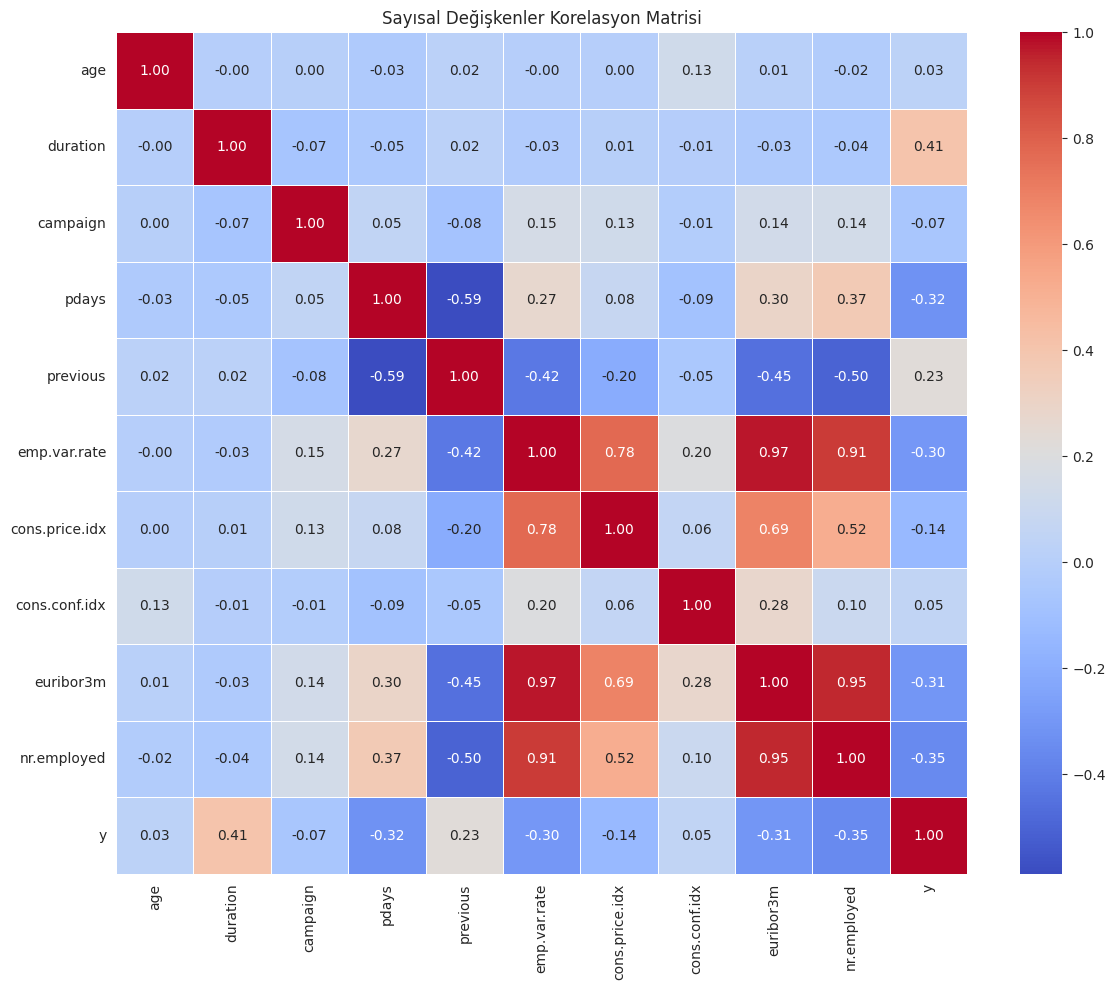

In [23]:
# 2. SAYISAL DEĞİŞKENLER İÇİN KORELASYON MATRİSİ

plt.figure(figsize=(12, 10))
numeric_data = df[numeric_cols + ['y']]
corr_matrix = numeric_data.corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Sayısal Değişkenler Korelasyon Matrisi')
plt.tight_layout()
plt.show()

In [24]:
# 3. MODELLERİ EĞİT VE DEĞERLENDİR

results = {}
predictions = {}
probas = {}

# KNN
knn = KNeighborsClassifier(n_neighbors=7, weights='distance')
knn.fit(X_train_scaled, y_train)
y_pred_knn = knn.predict(X_test_scaled)
y_proba_knn = knn.predict_proba(X_test_scaled)[:, 1]
results['KNN'] = accuracy_score(y_test, y_pred_knn)
predictions['KNN'] = y_pred_knn
probas['KNN'] = y_proba_knn
print(f"KNN -> Doğruluk: {results['KNN']:.4f}")

# SVM
svm = SVC(kernel='rbf', class_weight='balanced', random_state=42, probability=False)
svm.fit(X_train_scaled, y_train)
y_pred_svm = svm.predict(X_test_scaled)
y_decision_svm = svm.decision_function(X_test_scaled)
results['SVM'] = accuracy_score(y_test, y_pred_svm)
predictions['SVM'] = y_pred_svm
probas['SVM'] = y_decision_svm
print(f"SVM -> Doğruluk: {results['SVM']:.4f}")

# Karar Ağacı
param_dist = {
    'max_depth': [5, 7, 9, 11, 13, 15, 20, None],
    'min_samples_split': [2, 5, 10, 20, 50],
    'min_samples_leaf': [1, 2, 4, 8, 16],
    'criterion': ['gini', 'entropy'],
    'class_weight': ['balanced', None]
}
dt = DecisionTreeClassifier(random_state=42)
random_search = RandomizedSearchCV(dt, param_dist, n_iter=50, cv=5, scoring='accuracy',
                                   random_state=42, n_jobs=-1, verbose=0)
random_search.fit(X_train_scaled, y_train)
best_dt = random_search.best_estimator_
y_pred_dt = best_dt.predict(X_test_scaled)
y_proba_dt = best_dt.predict_proba(X_test_scaled)[:, 1]
results['Karar Ağacı'] = accuracy_score(y_test, y_pred_dt)
predictions['Karar Ağacı'] = y_pred_dt
probas['Karar Ağacı'] = y_proba_dt
print(f"Karar Ağacı (opt) -> Doğruluk: {results['Karar Ağacı']:.4f}")

# Random Forest
rf = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42, n_jobs=-1)
rf.fit(X_train_scaled, y_train)
y_pred_rf = rf.predict(X_test_scaled)
y_proba_rf = rf.predict_proba(X_test_scaled)[:, 1]
results['Random Forest'] = accuracy_score(y_test, y_pred_rf)
predictions['Random Forest'] = y_pred_rf
probas['Random Forest'] = y_proba_rf
print(f"Random Forest -> Doğruluk: {results['Random Forest']:.4f}")

# ANN
ann = Sequential([
    Dense(128, activation='relu', input_dim=X_train_scaled.shape[1]),
    Dropout(0.4),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])
ann.compile(optimizer=Adam(0.001), loss='binary_crossentropy', metrics=['accuracy'])
history_ann = ann.fit(X_train_scaled, y_train, validation_data=(X_test_scaled, y_test),
                      epochs=50, batch_size=256, callbacks=[EarlyStopping(patience=5, restore_best_weights=True)], verbose=0)
y_pred_ann = (ann.predict(X_test_scaled) > 0.5).astype(int)
y_proba_ann = ann.predict(X_test_scaled).flatten()
results['ANN'] = accuracy_score(y_test, y_pred_ann)
predictions['ANN'] = y_pred_ann
probas['ANN'] = y_proba_ann
print(f"ANN -> Doğruluk: {results['ANN']:.4f}")

# 1D CNN
X_train_cnn = X_train_scaled.reshape(X_train_scaled.shape[0], X_train_scaled.shape[1], 1)
X_test_cnn = X_test_scaled.reshape(X_test_scaled.shape[0], X_test_scaled.shape[1], 1)
cnn = Sequential([
    Conv1D(32, 3, activation='relu', input_shape=(X_train_cnn.shape[1], 1)),
    MaxPooling1D(2),
    Flatten(),
    Dense(64, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])
cnn.compile(optimizer=Adam(0.001), loss='binary_crossentropy', metrics=['accuracy'])
history_cnn = cnn.fit(X_train_cnn, y_train, validation_data=(X_test_cnn, y_test),
                      epochs=30, batch_size=256, callbacks=[EarlyStopping(patience=5)], verbose=0)
y_pred_cnn = (cnn.predict(X_test_cnn) > 0.5).astype(int)
y_proba_cnn = cnn.predict(X_test_cnn).flatten()
results['CNN'] = accuracy_score(y_test, y_pred_cnn)
predictions['CNN'] = y_pred_cnn
probas['CNN'] = y_proba_cnn
print(f"CNN -> Doğruluk: {results['CNN']:.4f}")

KNN -> Doğruluk: 0.9025
SVM -> Doğruluk: 0.8623
Karar Ağacı (opt) -> Doğruluk: 0.9187
Random Forest -> Doğruluk: 0.9159
258/258 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
258/258 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
ANN -> Doğruluk: 0.9202
258/258 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
258/258 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
CNN -> Doğruluk: 0.9154


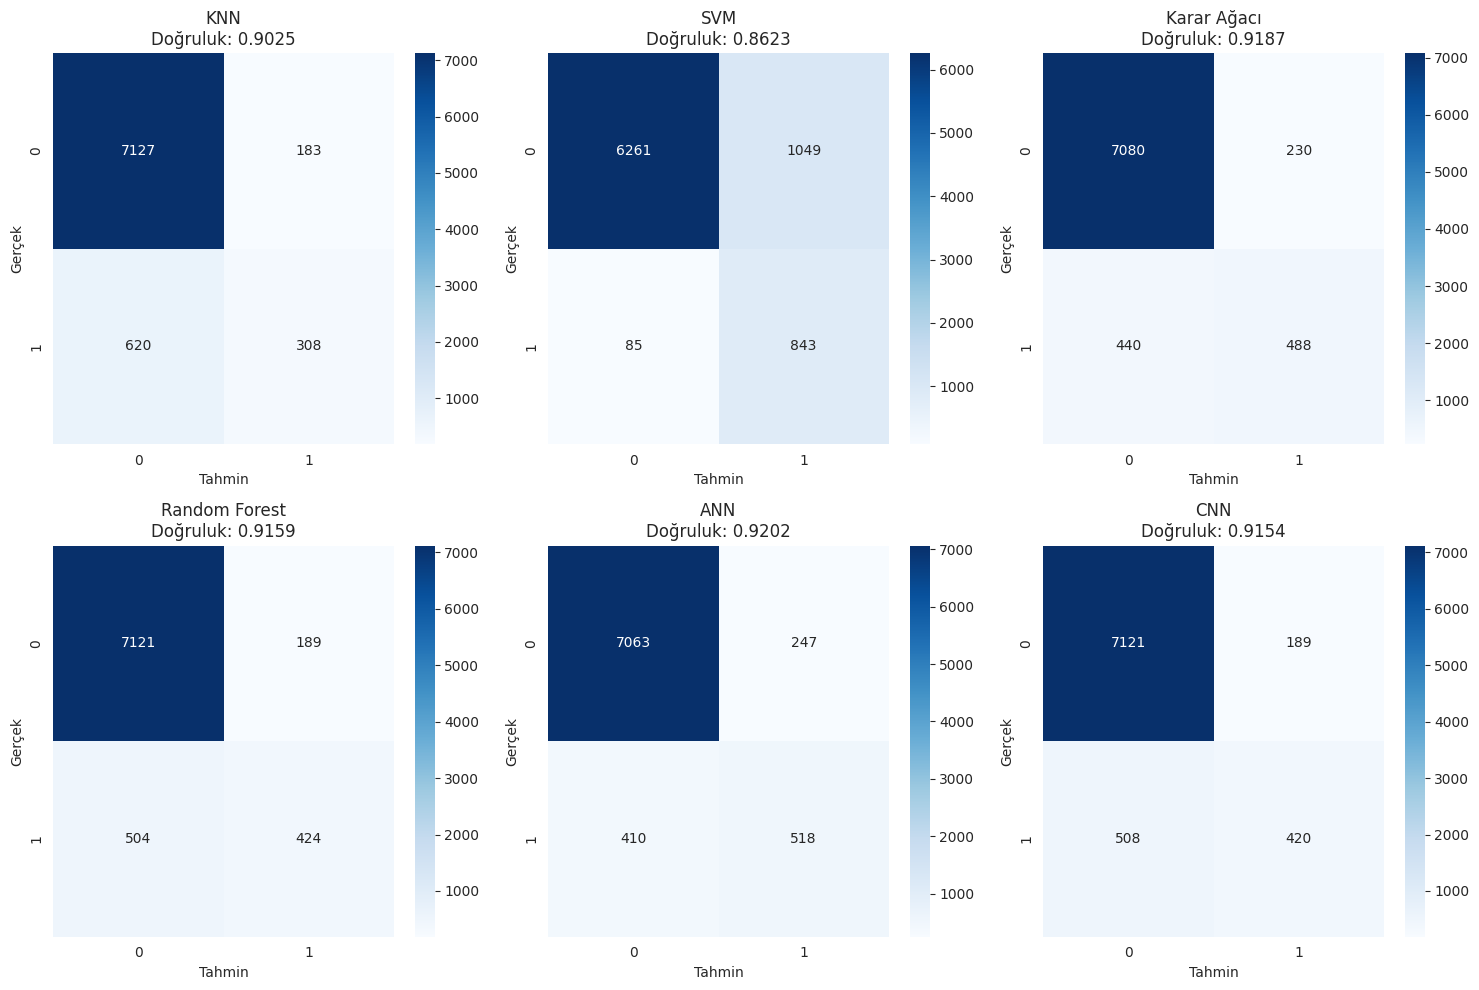

In [25]:
# 4. KARMAŞIKLIK MATRİSLERİ

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
model_list = list(predictions.items())
for idx, (name, pred) in enumerate(model_list):
    ax = axes[idx//3, idx%3]
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax)
    ax.set_title(f'{name}\nDoğruluk: {results[name]:.4f}')
    ax.set_xlabel('Tahmin')
    ax.set_ylabel('Gerçek')
plt.tight_layout()
plt.show()

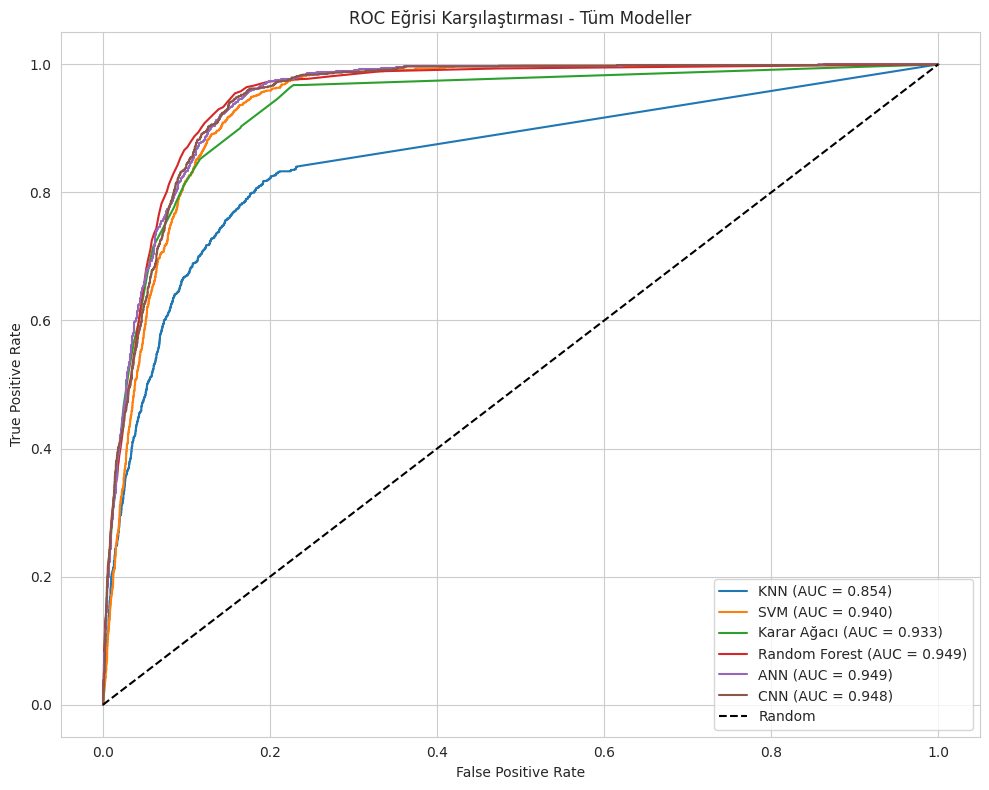

In [26]:
# 5. ROC EĞRİSİ KARŞILAŞTIRMASI

plt.figure(figsize=(10, 8))
for name, prob in probas.items():
    if name == 'SVM':
        fpr, tpr, _ = roc_curve(y_test, prob)
    else:
        fpr, tpr, _ = roc_curve(y_test, prob)
    auc = roc_auc_score(y_test, prob)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc:.3f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Eğrisi Karşılaştırması - Tüm Modeller')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

KNN hesaplanıyor... tamamlandı (23.8 sn)
SVM hesaplanıyor... tamamlandı (75.8 sn)
Karar Ağacı hesaplanıyor... tamamlandı (0.2 sn)
Random Forest hesaplanıyor... tamamlandı (17.7 sn)
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
tamamlandı (21.7 sn)
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
tamamlandı (23.0 sn)


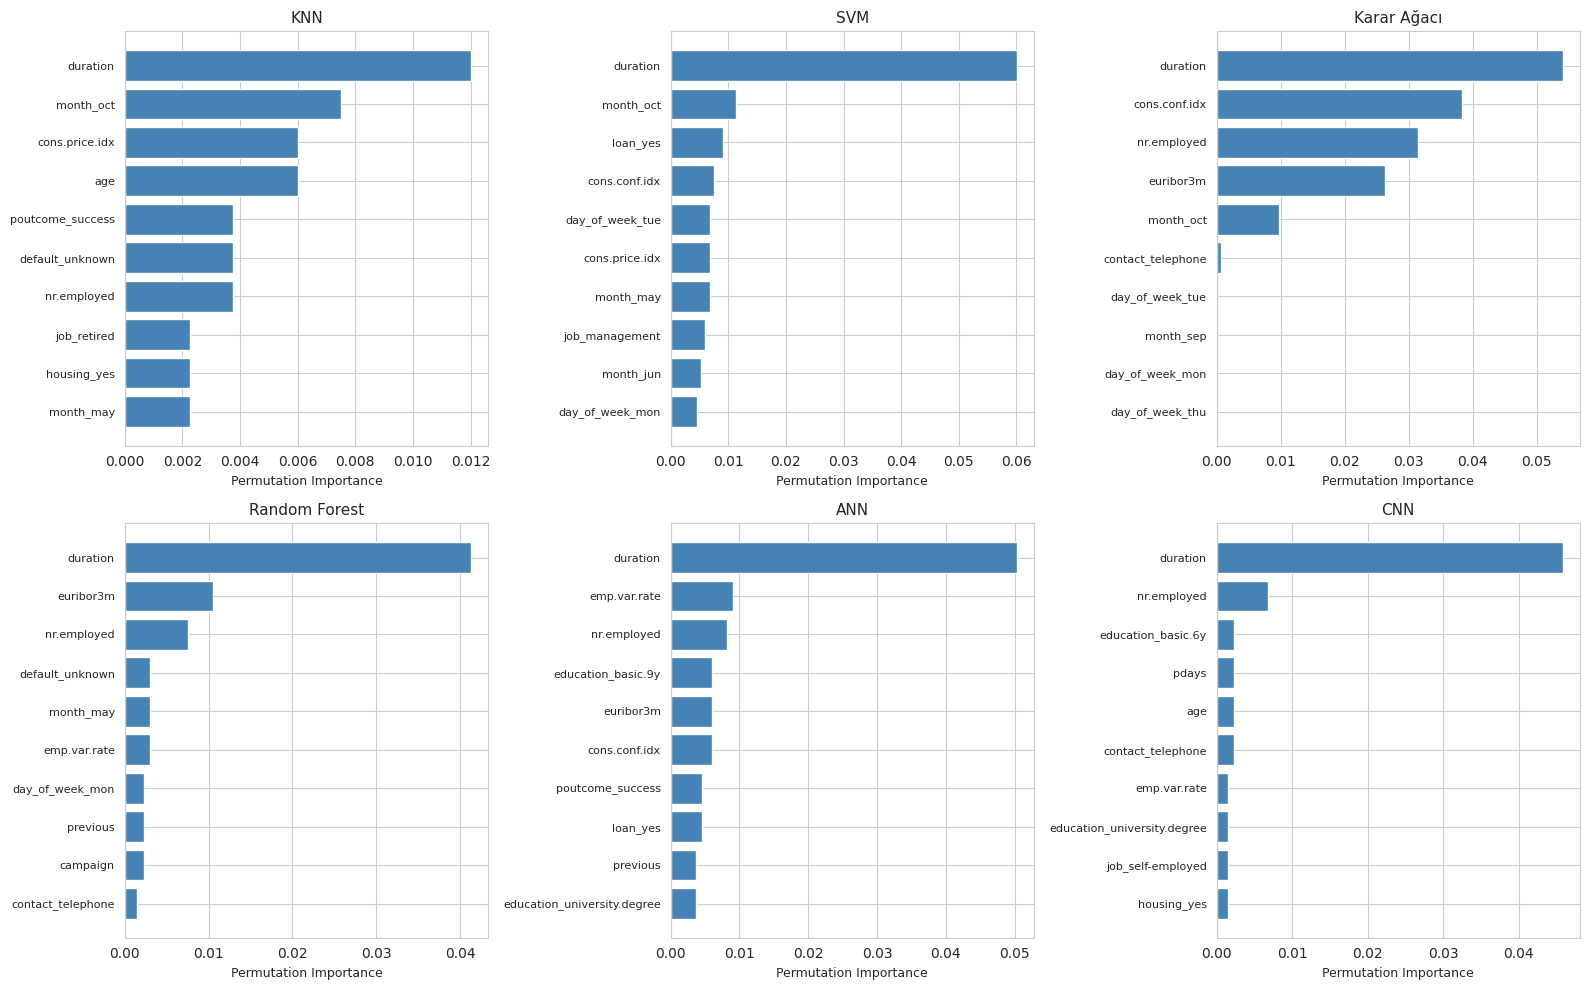

In [39]:
# ===================================================
# HIZLI PERMUTATION IMPORTANCE (Örneklem Küçültme)
# ===================================================
from sklearn.inspection import permutation_importance
import time
from sklearn.metrics import accuracy_score
from tensorflow.keras.layers import Conv1D # Import Conv1D for type checking

# Test setinden rastgele 500 örnek al (yeterli)
sample_size = 666
np.random.seed(42)
indices = np.random.choice(len(X_test_scaled), sample_size, replace=False)
X_sample = X_test_scaled[indices]
y_sample = y_test.iloc[indices] if isinstance(y_test, pd.Series) else y_test[indices]

# NOTE: X_sample_cnn will no longer be directly used as X_data for permutation_importance
# It's only needed for the CNN's predict method within the scorer.

models_fast = {
    'KNN': (knn, X_sample),
    'SVM': (svm, X_sample),
    'Karar Ağacı': (best_dt, X_sample),
    'Random Forest': (rf, X_sample),
    'ANN': (ann, X_sample),
    'CNN': (cnn, X_sample) # Pass 2D X_sample here, reshape inside scorer for CNN
}

feature_names = X.columns.tolist()
n_models = len(models_fast)
n_cols = 3
n_rows = (n_models + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 5*n_rows))
axes = axes.flatten()

def keras_accuracy_scorer(estimator, X_data, y_true):
    # Reshape X_data to 3D only if the estimator is a CNN (identified by its first layer type)
    if isinstance(estimator.layers[0], Conv1D):
        X_data_reshaped = X_data.reshape(X_data.shape[0], X_data.shape[1], 1)
    else:
        X_data_reshaped = X_data

    # Keras models' predict method returns probabilities. Convert to binary predictions.
    y_pred_proba = estimator.predict(X_data_reshaped, verbose=0) # Added verbose=0 here
    y_pred = (y_pred_proba > 0.5).astype(int)
    return accuracy_score(y_true, y_pred)


for idx, (name, (model, X_data)) in enumerate(models_fast.items()):
    start = time.time()
    print(f"{name} hesaplanıyor...", end=" ", flush=True)

    if name in ['ANN', 'CNN']:
        scorer = keras_accuracy_scorer
    else:
        scorer = 'accuracy'

    # permutation_importance will always receive a 2D X_data
    perm_imp = permutation_importance(model, X_data, y_sample, n_repeats=2,  # Sadece 2 tekrar
                                      scoring=scorer, random_state=42, n_jobs=-1)

    print(f"tamamlandı ({time.time()-start:.1f} sn)")

    # En önemli 10 özellik
    sorted_idx = perm_imp.importances_mean.argsort()[::-1][:10]
    importances = perm_imp.importances_mean[sorted_idx]
    features = [feature_names[i] for i in sorted_idx]

    ax = axes[idx]
    ax.barh(range(len(features)), importances, align='center', color='steelblue')
    ax.set_yticks(range(len(features)))
    ax.set_yticklabels(features, fontsize=8)
    ax.invert_yaxis()
    ax.set_xlabel('Permutation Importance', fontsize=9)
    ax.set_title(name, fontsize=11)

# Kullanılmayan grafikleri gizle
for idx in range(len(models_fast), len(axes)):
    axes[idx].axis('off')

plt.tight_layout()
plt.show()

 #Bu kısmda yapay zeka kullanıldı

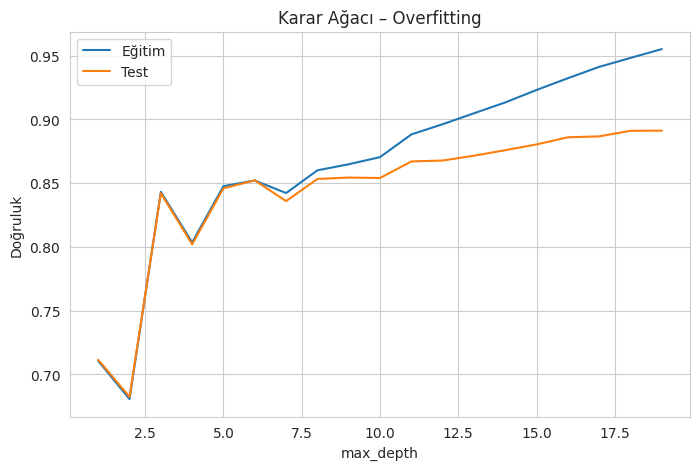

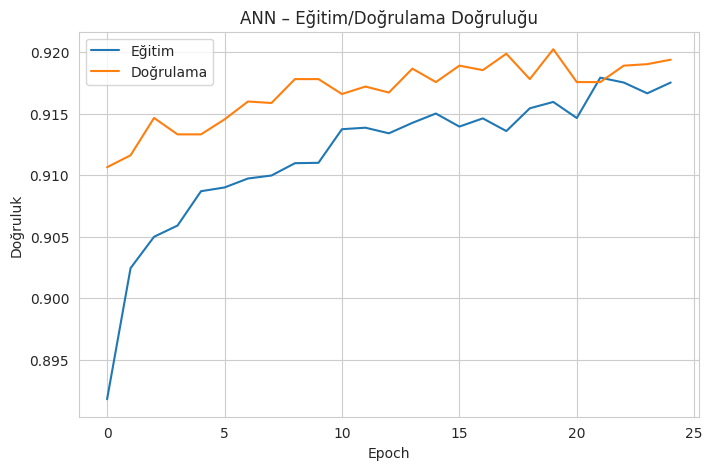

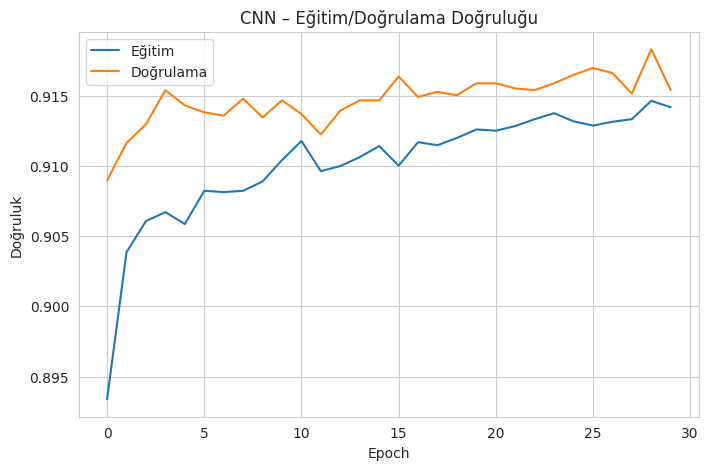

In [30]:
# 7. OVERFITTING ANALİZ GRAFİKLERİ
depths = range(1, 20)
train_scores, test_scores = [], []
for d in depths:
    dt_temp = DecisionTreeClassifier(max_depth=d, class_weight='balanced', random_state=42)
    dt_temp.fit(X_train_scaled, y_train)
    train_scores.append(accuracy_score(y_train, dt_temp.predict(X_train_scaled)))
    test_scores.append(accuracy_score(y_test, dt_temp.predict(X_test_scaled)))
plt.figure(figsize=(8,5))
plt.plot(depths, train_scores, label='Eğitim')
plt.plot(depths, test_scores, label='Test')
plt.xlabel('max_depth')
plt.ylabel('Doğruluk')
plt.title('Karar Ağacı – Overfitting')
plt.legend()
plt.show()

# ANN öğrenme eğrisi
plt.figure(figsize=(8,5))
plt.plot(history_ann.history['accuracy'], label='Eğitim')
plt.plot(history_ann.history['val_accuracy'], label='Doğrulama')
plt.title('ANN – Eğitim/Doğrulama Doğruluğu')
plt.xlabel('Epoch')
plt.ylabel('Doğruluk')
plt.legend()
plt.show()

# CNN öğrenme eğrisi
plt.figure(figsize=(8,5))
plt.plot(history_cnn.history['accuracy'], label='Eğitim')
plt.plot(history_cnn.history['val_accuracy'], label='Doğrulama')
plt.title('CNN – Eğitim/Doğrulama Doğruluğu')
plt.xlabel('Epoch')
plt.ylabel('Doğruluk')
plt.legend()
plt.show()

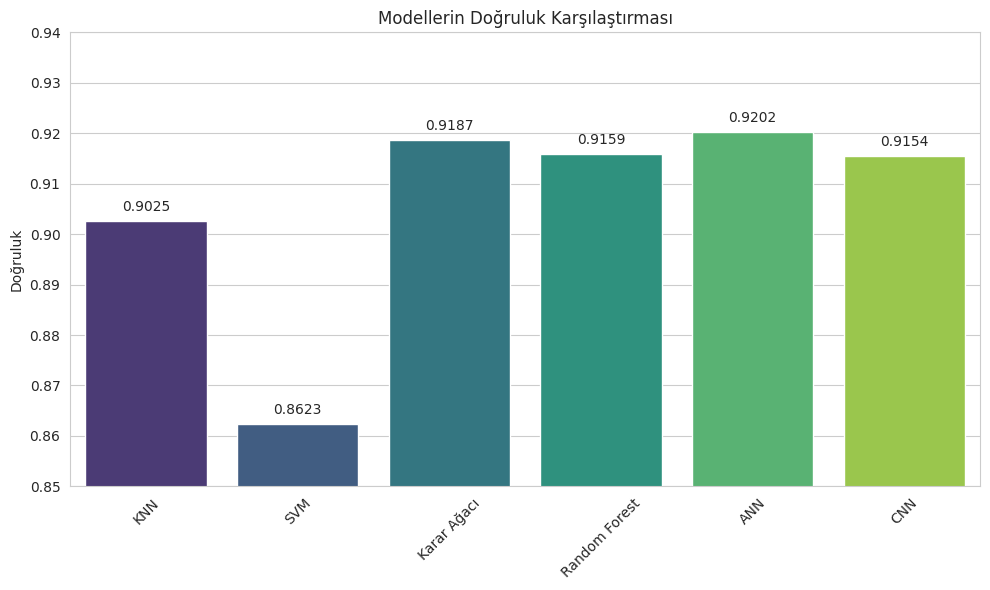

In [31]:
# 8. DOĞRULUK KARŞILAŞTIRMA GRAFİĞİ

plt.figure(figsize=(10,6))
names = list(results.keys())
accs = list(results.values())
sns.barplot(x=names, y=accs, palette='viridis')
plt.ylim(0.85, 0.94)
plt.ylabel('Doğruluk')
plt.title('Modellerin Doğruluk Karşılaştırması')
for i, v in enumerate(accs):
    plt.text(i, v+0.002, f"{v:.4f}", ha='center')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
# 9. ÖZET RAPORU

print("\n========== ÖZET ==========")
for name, acc in results.items():
    print(f"{name:20} Doğruluk: {acc:.4f}")

# En iyi modelin AUC skoru
best_model_name = max(results, key=results.get)
best_auc = roc_auc_score(y_test, probas[best_model_name])
print(f"\n En iyi model: {best_model_name} (Doğruluk: {results[best_model_name]:.4f}, AUC: {best_auc:.4f})")

# Her model için ek metrikler (precision, recall, f1-score) özeti
print("\n--SINIFLANDIRMA RAPORU--")
print("KNN \n"+classification_report(y_test, predictions['KNN']))
print("SVM \n"+classification_report(y_test, predictions['SVM']))
print("Karar Ağacı \n"+classification_report(y_test, predictions['Karar Ağacı']))
print("Random Forest \n"+classification_report(y_test, predictions['Random Forest']))
print("ANN \n"+classification_report(y_test, predictions['ANN']))
print("CNN \n"+classification_report(y_test, predictions['CNN']))


========== ÖZET ==========
KNN                  Doğruluk: 0.9025
SVM                  Doğruluk: 0.8623
Karar Ağacı          Doğruluk: 0.9187
Random Forest        Doğruluk: 0.9159
ANN                  Doğruluk: 0.9202
CNN                  Doğruluk: 0.9154

🏆 En iyi model: ANN (Doğruluk: 0.9202, AUC: 0.9490)

--SINIFLANDIRMA RAPORU--
KNN 
              precision    recall  f1-score   support

           0       0.92      0.97      0.95      7310
           1       0.63      0.33      0.43       928

    accuracy                           0.90      8238
   macro avg       0.77      0.65      0.69      8238
weighted avg       0.89      0.90      0.89      8238

SVM 
              precision    recall  f1-score   support

           0       0.99      0.86      0.92      7310
           1       0.45      0.91      0.60       928

    accuracy                           0.86      8238
   macro avg       0.72      0.88      0.76      8238
weighted avg       0.93      0.86      0.88      8238

K